# Reelvana — Exploratory Data Analysis

**CST3104 Software Development Workshop II · Spring 2025-2026**

This notebook is the **source for the written report** (5/20) and **PPT** (5/25-29).
It mirrors the live web dashboard's analysis (`/analysis`), but renders charts as
static PNG (300dpi for slides) and PDF (vector for report) using matplotlib.

**Data:** TMDB + MovieLens, films released ≤ July 2017.

**Architecture:** All chart data is computed by `analysis.py` (the same module the
dashboard uses). This notebook only provides the matplotlib rendering layer + commentary,
guaranteeing notebook numbers match dashboard numbers.

**Sections:**
- **0** — Data Loading & Overview
- **1** — Q1: Genre & Era Trends (3 charts)
- **2** — Q2: Financial Performance (3 charts)

> Audience / rating-trend charts (Q3) are dashboard-exclusive and intentionally
> not duplicated here.

## 0. Setup & Data Loading

In [1]:
# Path setup — notebook is in notebooks/, project modules are at ../
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plot_style import (
    apply_reelvana_style, save_figure, add_titles, add_source,
    REELVANA_PALETTE, REELVANA_SEQUENTIAL, REELVANA_DIVERGING,
    BG_PRIMARY, BG_PANEL, TEXT_PRIMARY, TEXT_SEC, TEXT_MUTED,
)

apply_reelvana_style()

# Load cleaned dataset via the same loader used by the Flask app
from data_loader import load_movies
df, genres = load_movies()

print(f"Loaded {len(df):,} films · {len(genres)} canonical genres")

[data_loader] Sanity filter dropped 93 additional column-shifted rows.


Loaded 22,620 films · 20 canonical genres


### 0.1 Dataset overview

The cleaning pipeline (`data_loader.load_movies`) handled three classes of issues
in the source CSV:
1. **Encoding errors** — `encoding_errors='replace'` for malformed UTF-8 bytes
2. **CSV column-shift corruption** — 100 rows dropped (7 with NaN title + 93 with
   implausible vote_average / release_year / garbled title)
3. **Genre vocabulary drift** — restricted to 20 canonical TMDB genres

In [2]:
# Basic shape + year coverage
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Year range: {int(df['release_year'].min())} – {int(df['release_year'].max())}")
print(f"Decades represented: {df['release_decade'].dropna().nunique()}")
print(f"Films with disclosed budget+revenue: {((df['budget'] > 0) & (df['revenue'] > 0)).sum():,}")
print(f"Films with poster image on disk: {df['poster_url'].notna().sum():,}")

Shape: 22,620 rows × 35 columns
Year range: 1874 – 2017
Decades represented: 15
Films with disclosed budget+revenue: 5,083
Films with poster image on disk: 4,841


In [3]:
# Missing-rate ranking — tells us which fields are usable for analysis
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]
display_cols = ["budget", "revenue", "profit", "roi", "primary_genre",
                "vote_average", "vote_count", "runtime", "overview", "director"]
print("Missing rates (key analysis columns):")
for col in display_cols:
    if col in df.columns:
        pct = (df[col].isna().mean() * 100)
        print(f"  {col:<18} {pct:>6.2f}% missing")

Missing rates (key analysis columns):
  budget              66.77% missing
  revenue             70.29% missing
  profit              77.51% missing
  roi                 77.43% missing
  primary_genre        0.69% missing
  vote_average         0.10% missing
  vote_count           0.03% missing
  runtime              1.11% missing
  overview             0.00% missing
  director             0.01% missing


In [4]:
# Numeric describe — the headline statistics
df[["vote_average", "vote_count", "runtime", "budget", "revenue", "roi"]].describe().round(2)

,vote_average,vote_count,runtime,budget,revenue,roi
count,22597.00,22614.00,2.236800e+04,7.517000e+03,6.720000e+03,5.105000e+03
mean,6.18,215.13,1.393531e+04,2.488916e+07,7.489065e+07,2.914622e+04
std,1.00,677.53,1.367901e+06,3.605837e+07,1.517724e+08,1.715390e+06
min,0.00,4.80,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,5.60,17.00,9.000000e+01,3.500000e+06,4.039886e+06,8.400000e-01
50%,6.30,34.00,9.800000e+01,1.200000e+07,2.046486e+07,2.130000e+00
75%,6.90,109.75,1.110000e+02,3.000000e+07,7.585573e+07,4.340000e+00
max,9.50,14075.00,1.778568e+08,3.800000e+08,2.787965e+09,1.215631e+08


## 1. Q1 — Genre & Era Trends

How has cinema's volume and genre composition evolved across 14 decades?

### 1.1 Production Trend by Decade

A century-and-a-half timeline of film production volume, anchored to three
industry inflection points: the Sound Era (1927), the Blockbuster Era (1977),
and the Digital Era (1995).

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


...

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


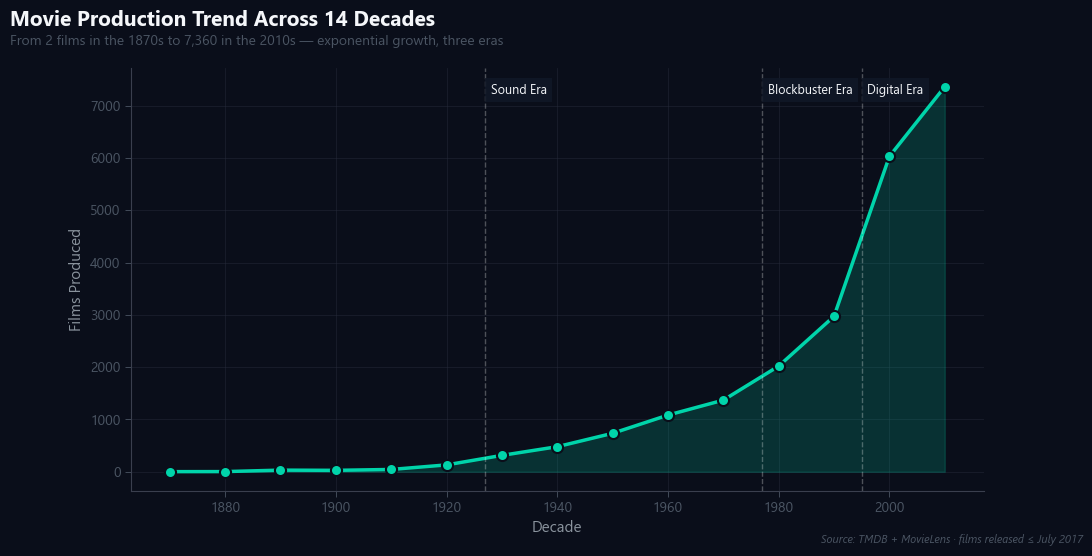

In [5]:
from analysis import production_trend_by_decade

data = production_trend_by_decade(df)
decades, counts = data["decades"], data["counts"]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.fill_between(decades, counts, alpha=0.18, color=REELVANA_PALETTE[0])
ax.plot(decades, counts, marker="o", color=REELVANA_PALETTE[0],
        linewidth=2.5, markersize=8, markeredgecolor=BG_PRIMARY, markeredgewidth=1.5)

# Era inflection-point annotations
eras = [(1927, "Sound Era"), (1977, "Blockbuster Era"), (1995, "Digital Era")]
y_top = ax.get_ylim()[1] * 0.96
for year, label in eras:
    ax.axvline(year, color="white", alpha=0.28, linestyle="--", linewidth=1)
    ax.text(year + 1, y_top, label, fontsize=9, color=TEXT_PRIMARY,
            ha="left", va="top",
            bbox=dict(facecolor=BG_PANEL, edgecolor="none", pad=4, alpha=0.85))

ax.set_xlabel("Decade")
ax.set_ylabel("Films Produced")
add_titles(fig, "Movie Production Trend Across 14 Decades",
           "From 2 films in the 1870s to 7,360 in the 2010s — exponential growth, three eras")
add_source(fig)

save_figure(fig, "q1_1_production_trend")
plt.show()

**Key insight:** The 2010s alone produced **7,360 films** — about **1.7×** the
entire 1870-1970 century combined. Production grew exponentially through the
20th century and accelerated sharply in the digital era. The Sound Era (1927)
catalyzed the first major inflection; television (1950s) briefly suppressed
output; home video and digital cinema (1990s+) drove the steepest gains.

### 1.2 Genre Composition Evolution

A percentage-stacked area chart showing how the **share** of each top genre
has shifted decade by decade. Filtered to decades with ≥50 films to avoid the
small-sample noise of the very early eras.

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


...

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


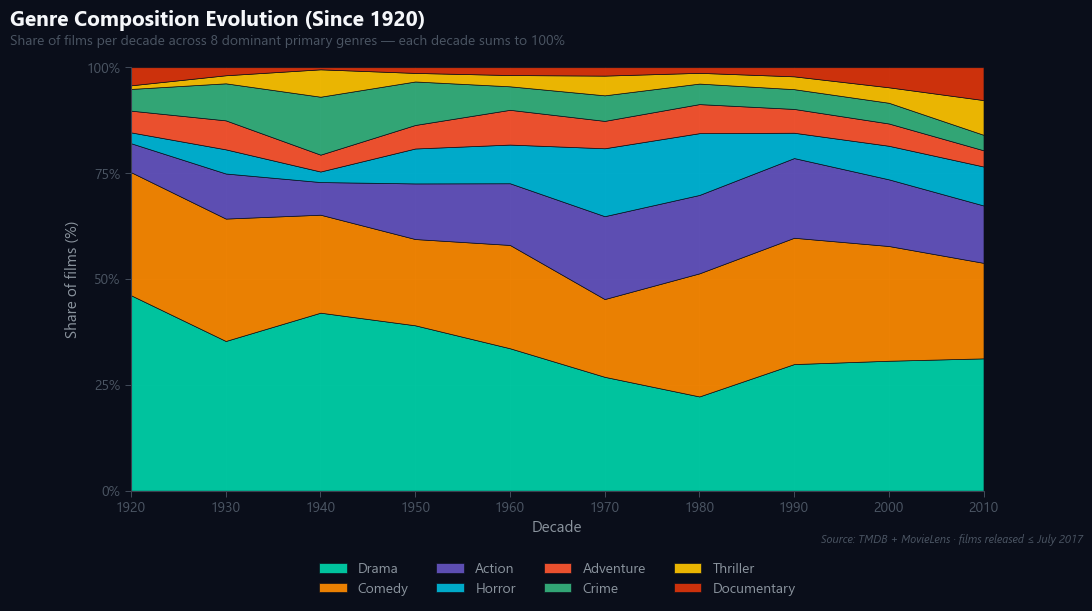

In [6]:
from analysis import genre_evolution_by_decade

data = genre_evolution_by_decade(df)
decades = data["decades"]
genres = data["genres"]
matrix = np.array(data["matrix"]) * 100  # percentage

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.stackplot(decades, matrix.T, labels=genres,
             colors=REELVANA_PALETTE[:len(genres)], alpha=0.92,
             edgecolor=BG_PRIMARY, linewidth=0.5)

ax.set_xlim(decades[0], decades[-1])
ax.set_ylim(0, 100)
ax.set_xlabel("Decade")
ax.set_ylabel("Share of films (%)")
add_titles(fig, "Genre Composition Evolution (Since 1920)",
           "Share of films per decade across 8 dominant primary genres — each decade sums to 100%")

# Format y-ticks as percentages
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14),
          ncol=4, frameon=False, fontsize=10)
add_source(fig)

save_figure(fig, "q1_2_genre_evolution")
plt.show()

**Key insight:** Drama has held the #1 share in every decade since 1920.
**Documentary's share grew 66%** from 2000s (4.7%) to 2010s (7.8%) — the
fastest-growing genre of the streaming era. Action and Crime have held
relatively stable shares since the 1980s, while Comedy's share has been
gradually eroded.

### 1.3 Genre × Decade Heatmap

The same data as 1.2, displayed as a heatmap to make individual cells
comparable across both axes. Color scale is capped at 60% so modern-era
variation isn't dominated by any single dominant cell.

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


...

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


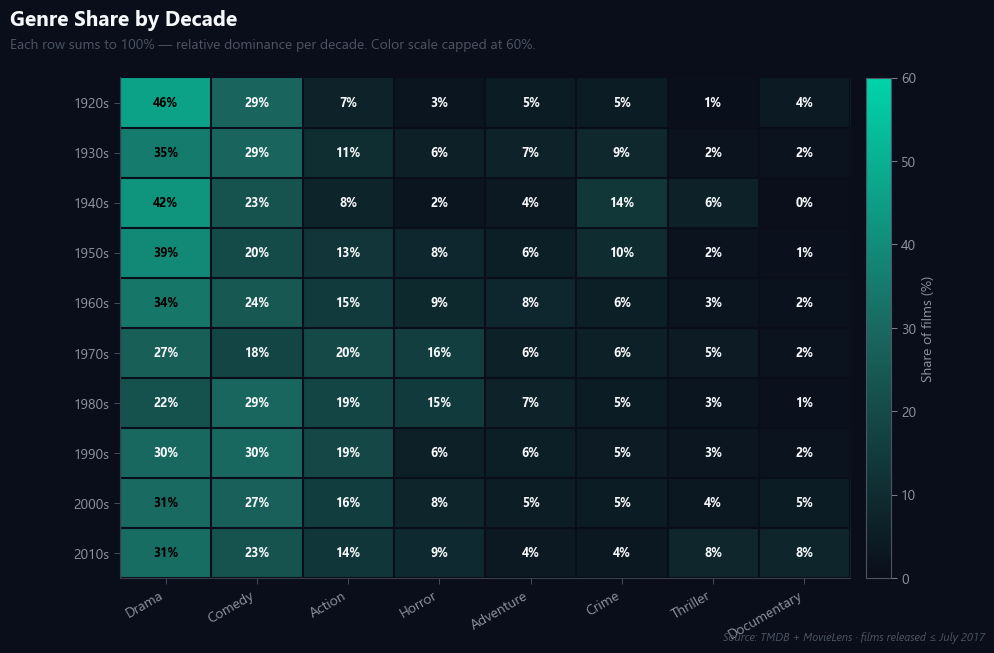

In [7]:
from analysis import genre_decade_heatmap

data = genre_decade_heatmap(df)
genres = data["genres"]
decade_labels = [f"{d}s" for d in data["decades"]]
matrix = np.array(data["matrix"]) * 100  # percentage

fig, ax = plt.subplots(figsize=(10, 6.5))
im = ax.imshow(matrix, cmap=REELVANA_SEQUENTIAL, vmin=0, vmax=60, aspect="auto")

ax.set_xticks(range(len(genres)))
ax.set_xticklabels(genres, rotation=30, ha="right", color=TEXT_SEC)
ax.set_yticks(range(len(decade_labels)))
ax.set_yticklabels(decade_labels, color=TEXT_SEC)

# Numeric annotations in each cell
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        v = matrix[i, j]
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center",
                color="black" if v > 30 else TEXT_PRIMARY, fontsize=9, fontweight="bold")

# White cell separators
for i in range(matrix.shape[0] + 1):
    ax.axhline(i - 0.5, color=BG_PRIMARY, linewidth=1.5)
for j in range(matrix.shape[1] + 1):
    ax.axvline(j - 0.5, color=BG_PRIMARY, linewidth=1.5)

add_titles(fig, "Genre Share by Decade",
           "Each row sums to 100% — relative dominance per decade. Color scale capped at 60%.")
ax.grid(False)

cbar = fig.colorbar(im, ax=ax, fraction=0.038, pad=0.02)
cbar.ax.tick_params(colors=TEXT_SEC)
cbar.set_label("Share of films (%)", color=TEXT_SEC, fontsize=10)
cbar.outline.set_edgecolor(TEXT_MUTED)

add_source(fig)

save_figure(fig, "q1_3_genre_heatmap")
plt.show()

**Key insight:** Drama's dominance peaked in the **1990s at ~30%** and has
slowly declined since. Documentary has more than doubled its share (3% → 8%)
across the post-2000 era. Genres reading right-to-left (Drama, Comedy,
Action) form the "established core"; Crime, Adventure, and especially
Documentary represent the modern shift.

## 2. Q2 — Financial Performance

What do disclosed budgets and revenues tell us about the economics of cinema?
All charts in this section use only films with both `budget ≥ $1,000` and
`revenue > 0` disclosed (5,047 films — about 22% of the dataset).

### 2.1 Budget vs Revenue (Log-Log)

A scatter plot with a linear regression fit performed in log-log space. The
slope of the log-log fit is a **price elasticity**: a 1% increase in budget
yields ~`slope`% increase in revenue.

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


...

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


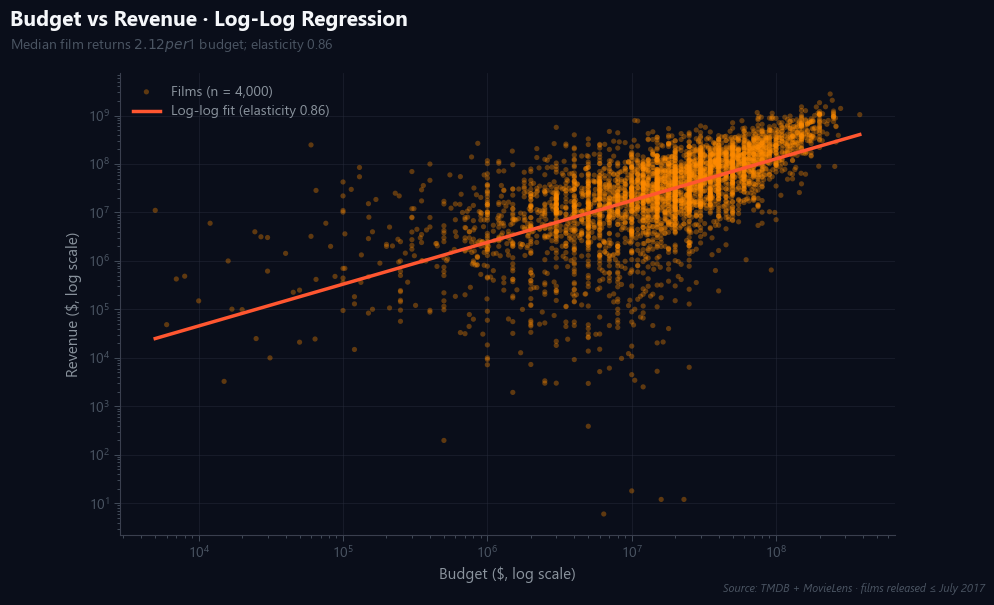

In [8]:
from analysis import budget_revenue_scatter

data = budget_revenue_scatter(df)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(data["budget"], data["revenue"],
           s=14, alpha=0.35, color=REELVANA_PALETTE[1],
           edgecolors="none", label=f"Films (n = {data['n_plotted']:,})")

ax.plot(data["regression"]["x"], data["regression"]["y"],
        color="#FF5630", linewidth=2.5,
        label=f"Log-log fit (elasticity {data['regression']['slope']:.2f})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Budget ($, log scale)")
ax.set_ylabel("Revenue ($, log scale)")
add_titles(fig, "Budget vs Revenue · Log-Log Regression",
           f"Median film returns ${data['median_ratio']:.2f} per $1 budget; elasticity {data['regression']['slope']:.2f}")

ax.legend(loc="upper left", fontsize=10)
add_source(fig)

save_figure(fig, "q2_1_budget_revenue")
plt.show()

**Key insight:** The median film returns **$2.12 per $1 of budget**. The
log-log elasticity is **0.86**, meaning revenue grows slightly *slower* than
budget — diminishing returns at the high end. This explains why mid-budget
filmmaking can be more profitable per dollar than blockbuster spending.

### 2.2 ROI Distribution by Genre

A boxplot showing return-on-investment (ROI = revenue ÷ budget) per genre,
filtered to films that at least broke even (1× ≤ ROI ≤ 50×). Y-axis is log
scale to show median differences clearly. Genres are sorted left-to-right by
median ROI descending.

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


...

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


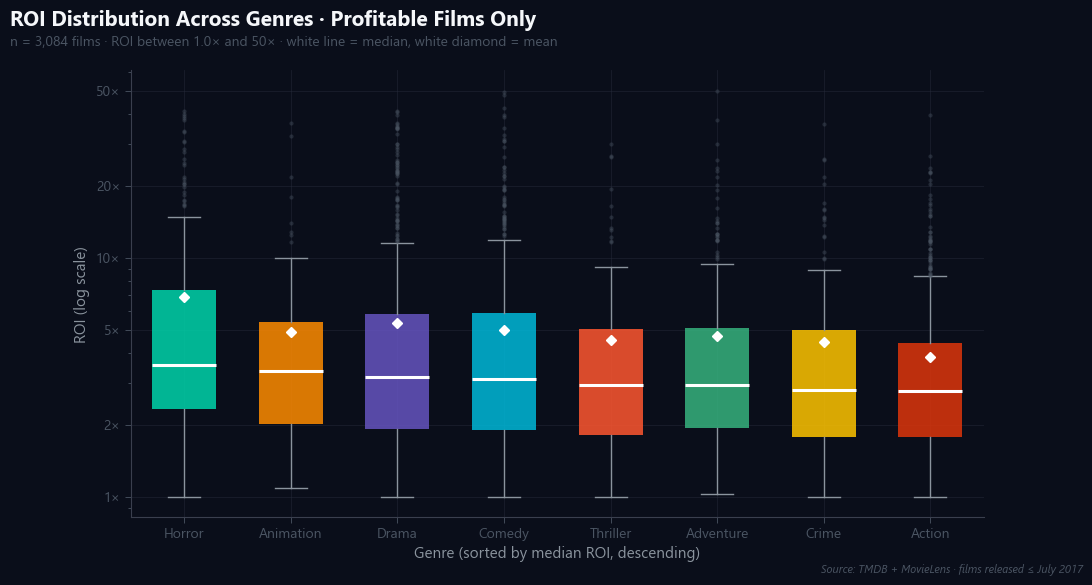

In [9]:
from analysis import roi_by_genre_box

data = roi_by_genre_box(df)
genres = data["genres"]
roi_values = [data["roi_by_genre"][g] for g in genres]

fig, ax = plt.subplots(figsize=(11, 5.8))

bp = ax.boxplot(
    roi_values, tick_labels=genres, patch_artist=True, widths=0.6, showmeans=True,
    medianprops=dict(color="white", linewidth=2.2),
    meanprops=dict(marker="D", markerfacecolor="white",
                   markeredgecolor="white", markersize=5),
    whiskerprops=dict(color=TEXT_SEC, linewidth=1),
    capprops=dict(color=TEXT_SEC, linewidth=1),
    flierprops=dict(marker="o", markerfacecolor=TEXT_MUTED,
                    markeredgecolor="none", markersize=3, alpha=0.4),
)
for patch, color in zip(bp["boxes"], REELVANA_PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor("none")

ax.set_yscale("log")
ax.set_yticks([1, 2, 5, 10, 20, 50])
ax.set_yticklabels(["1×", "2×", "5×", "10×", "20×", "50×"])
ax.set_ylabel("ROI (log scale)")
ax.set_xlabel("Genre (sorted by median ROI, descending)")
add_titles(fig, "ROI Distribution Across Genres · Profitable Films Only",
           f"n = {data['n_movies']:,} films · ROI between {data['roi_min']}× and {data['roi_cap']}× · white line = median, white diamond = mean")

add_source(fig)

save_figure(fig, "q2_2_roi_by_genre")
plt.show()

**Key insight:** Among films that broke even, **Horror leads at 3.55× median
return**, edging Animation (3.37×) and Drama (3.18×). Action, Crime, and
Thriller cluster at the bottom (~2.8×). The "micro-budget magic" of horror
and animation extracts the most leverage per dollar — a finding consistent
across the rating-vs-economics divide (Horror tops ROI but bottoms ratings).

### 2.3 Financial Metrics Correlation Matrix

Pearson correlation between the five financial/runtime variables, computed on
the disclosed-financial subset. Cells with |r| < 0.05 are dimmed as effectively
zero noise.

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


...

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


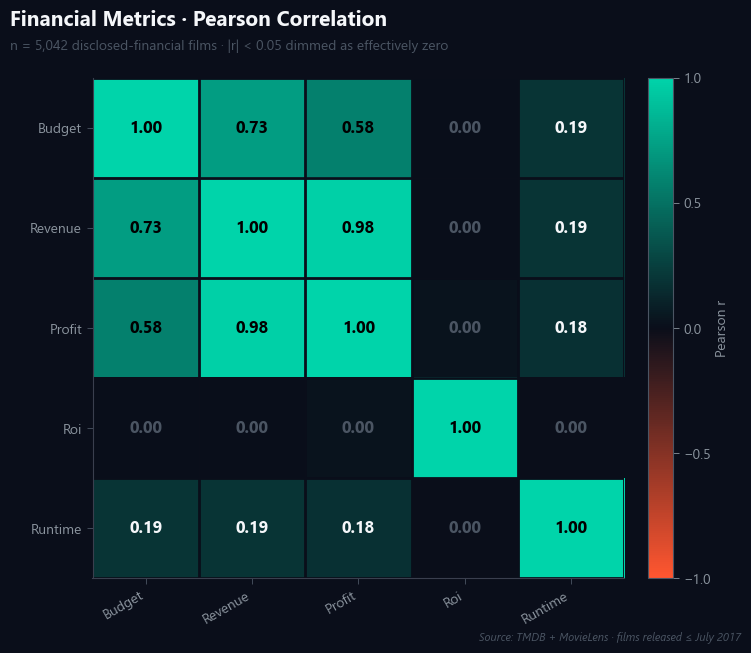

In [10]:
from analysis import financial_correlation

data = financial_correlation(df)
labels = data["variables"]
matrix = np.array(data["matrix"])

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(matrix, cmap=REELVANA_DIVERGING, vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right", color=TEXT_SEC)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, color=TEXT_SEC)

for i in range(len(labels)):
    for j in range(len(labels)):
        v = matrix[i, j]
        if abs(v) < 0.05:
            text, color = "0.00", TEXT_MUTED
        else:
            text = f"{v:.2f}"
            color = "black" if abs(v) > 0.5 else TEXT_PRIMARY
        ax.text(j, i, text, ha="center", va="center",
                color=color, fontsize=12, fontweight="bold")

# White cell separators
for i in range(matrix.shape[0] + 1):
    ax.axhline(i - 0.5, color=BG_PRIMARY, linewidth=2)
for j in range(matrix.shape[1] + 1):
    ax.axvline(j - 0.5, color=BG_PRIMARY, linewidth=2)

ax.grid(False)
add_titles(fig, "Financial Metrics · Pearson Correlation",
           f"n = {data['n_movies']:,} disclosed-financial films · |r| < 0.05 dimmed as effectively zero")

cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04)
cbar.ax.tick_params(colors=TEXT_SEC)
cbar.set_label("Pearson r", color=TEXT_SEC, fontsize=10)
cbar.outline.set_edgecolor(TEXT_MUTED)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

add_source(fig)

save_figure(fig, "q2_3_financial_correlation")
plt.show()

**Key insight:** Revenue and Profit move in **lockstep (r = 0.98)** — for
disclosed films, profit is essentially a linear function of revenue (since
budgets are dwarfed by hits). Budget correlates moderately with both revenue
(0.73) and profit (0.58), confirming bigger productions tend to gross more
but also incur larger absolute losses on flops. Critically, **ROI is
uncorrelated with everything** (|r| < 0.05) — small-budget films can win
disproportionately, and budget size does not predict efficiency.

## Summary

This notebook generated 6 publication-ready figures in `notebooks/figures/`
(both PNG @ 300dpi for slides and PDF for the report):

| File | Section | Chart |
|------|---------|-------|
| `q1_1_production_trend.{png,pdf}` | 1.1 | Production trend by decade |
| `q1_2_genre_evolution.{png,pdf}`  | 1.2 | Genre evolution (stacked area) |
| `q1_3_genre_heatmap.{png,pdf}`    | 1.3 | Genre × decade heatmap |
| `q2_1_budget_revenue.{png,pdf}`   | 2.1 | Budget vs revenue scatter + regression |
| `q2_2_roi_by_genre.{png,pdf}`     | 2.2 | ROI box plot by genre |
| `q2_3_financial_correlation.{png,pdf}` | 2.3 | Financial correlation matrix |

All numbers are computed by `analysis.py`, the same module powering the live
dashboard at `/analysis`. Re-running this notebook regenerates the figures
with the latest data — single source of truth, no duplication.